### Assignment-1

In [2]:
import pandas as pd
import numpy as np

# Load preprocessed data from the same folder
df = pd.read_csv('../Day_8/preprocessed_earthquake_data.csv')

print("Loaded successfully:", df.shape)
df.head()


Loaded successfully: (109848, 15)


,latitude,longitude,depth,mag,magType,rms,type,status,Year,Month,Day,Hour,Minute,Second,DayOfWeek
0,1.254896,-0.152401,-0.430517,3.296720,mw,0.255959,earthquake,reviewed,1904,4,4,10,26,0,0
1,1.256343,-0.153559,-0.430517,2.920854,mw,0.227615,earthquake,reviewed,1904,4,4,10,2,34,0
2,1.616780,0.972437,-0.291162,4.716657,mw,0.360656,earthquake,reviewed,1904,6,25,21,0,38,5
3,1.572749,0.983609,-0.430517,4.299028,mw,0.331543,earthquake,reviewed,1904,6,25,14,45,39,5
4,0.890744,0.482625,-0.430517,3.442890,mw,0.266982,earthquake,reviewed,1904,8,30,11,43,20,1


Q1. Analyze the distribution of earthquake magnitudes (mag) and explore how they vary across different earthquake types (type) using visualizations such as boxplots or violin plots.

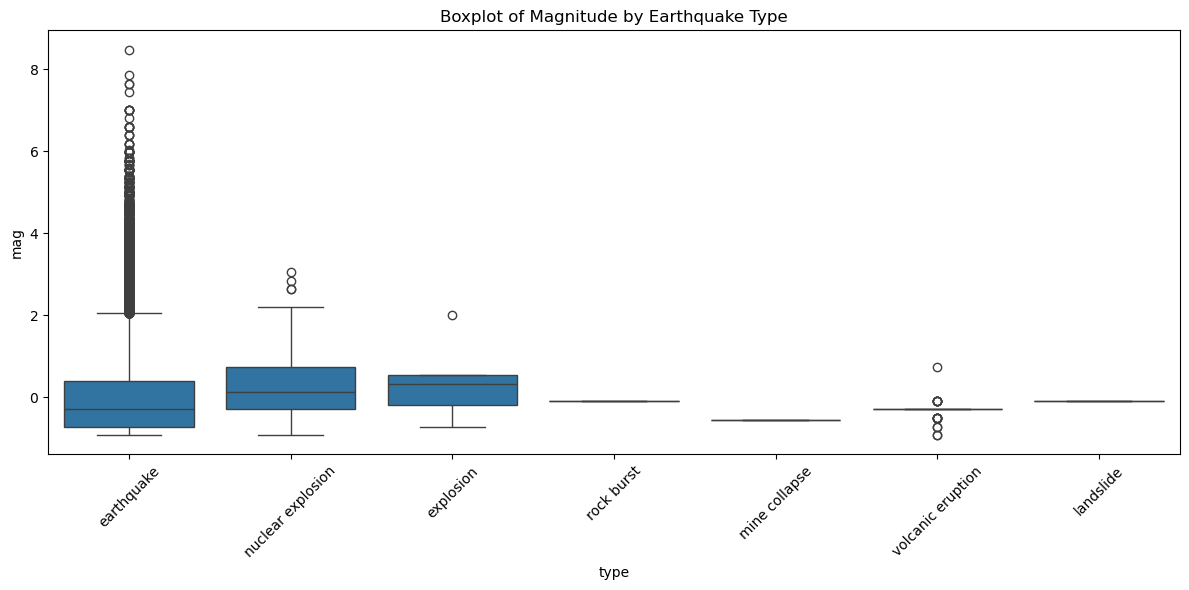

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
if not df.empty and 'mag' in df.columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x='type', y='mag')
    plt.title('Boxplot of Magnitude by Earthquake Type')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Q2. Explore the relationship between earthquake depth (depth) and magnitude (mag). Is there a trend or correlation between these two features in the dataset?

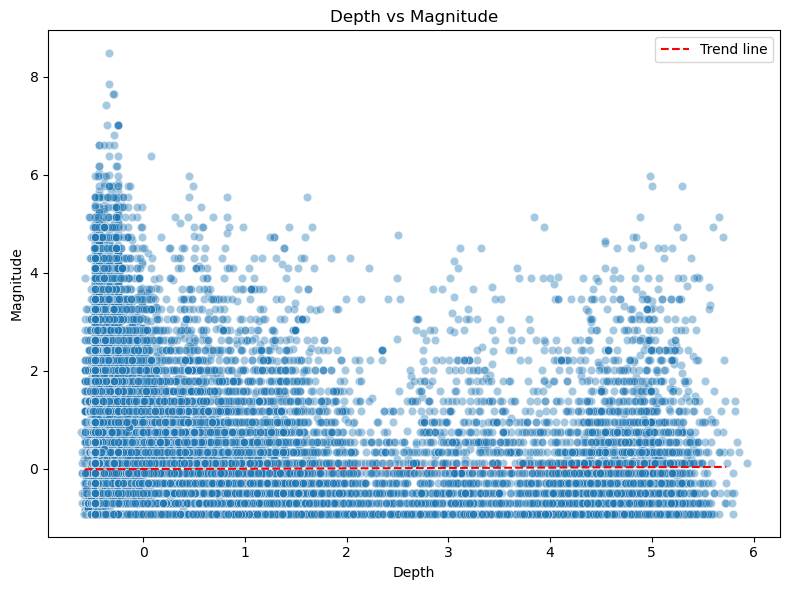

Pearson correlation depth vs mag: -0.010 (p=0.000868)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

if not df.empty and set(['depth', 'mag']).issubset(df.columns):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x='depth', y='mag', alpha=0.4)

    try:
        sample = df.dropna(subset=['depth', 'mag']).sample(n=min(5000, len(df)))
        z = np.polyfit(sample['depth'], sample['mag'], 1)
        p = np.poly1d(z)
        xs = np.linspace(sample['depth'].min(), sample['depth'].max(), 100)
        plt.plot(xs, p(xs), linestyle='--', color='red', label='Trend line')
    except Exception as e:
        print('Could not fit regression line:', e)

    plt.xlabel('Depth')
    plt.ylabel('Magnitude')
    plt.title('Depth vs Magnitude')
    plt.legend()
    plt.tight_layout()
    plt.show()

    try:
        # Drop rows with missing values in depth or mag before correlation
        corr_data = df[['depth', 'mag']].dropna()
        corr, pval = pearsonr(corr_data['depth'], corr_data['mag'])
        print(f'Pearson correlation depth vs mag: {corr:.3f} (p={pval:.3g})')
    except Exception as e:
        print('Could not compute correlation:', e)
else:
    print('DataFrame empty or missing depth/mag columns; cannot plot Q2.')


Q3. Using the preprocessed temporal features (Year, Month, Day, Hour), investigate if there is any difference in earthquake frequency or magnitude over months or years. Visualize temporal trends clearly.

In [5]:
import pandas as pd

# Load your dataset (replace 'earthquakes.csv' with your actual file path)


# Check for negative magnitude values
negative_mags = df[df['mag'] < 0]

# Display how many and preview them
print(f"Number of negative magnitudes: {len(negative_mags)}")
print(negative_mags[[ 'mag', 'depth']].head())


Number of negative magnitudes: 69616
         mag     depth
20 -0.294885 -0.430517
24 -0.127834 -0.430517
27 -0.002545 -0.430517
47 -0.482818 -0.430517
48 -0.190478 -0.430517


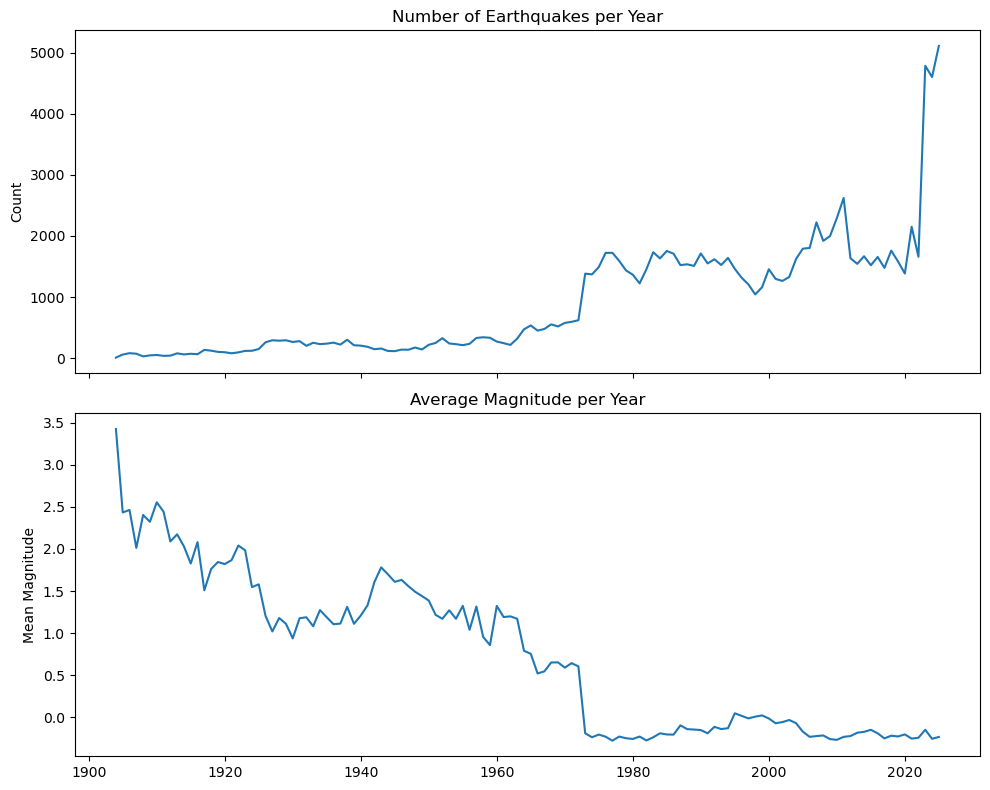

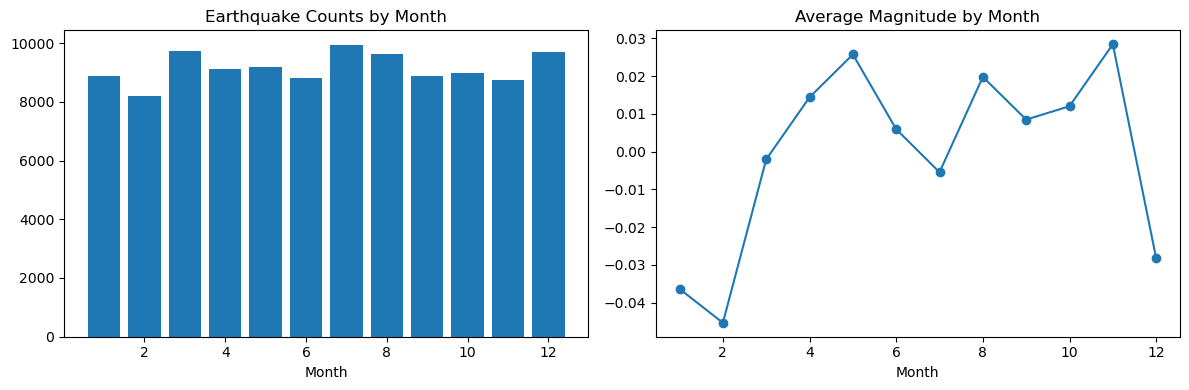

In [6]:
if not df.empty and 'Year' in df.columns:
    # Yearly analysis
    yearly = df.groupby('Year').size()
    yearly_mean_mag = df.groupby('Year')['mag'].mean()

    fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    ax[0].plot(yearly.index, yearly.values)
    ax[0].set_title('Number of Earthquakes per Year')
    ax[0].set_ylabel('Count')

    ax[1].plot(yearly_mean_mag.index, yearly_mean_mag.values)
    ax[1].set_title('Average Magnitude per Year')
    ax[1].set_ylabel('Mean Magnitude')

    plt.tight_layout()
    plt.show()

    # Monthly analysis
    if 'Month' in df.columns:
        monthly_counts = df.groupby('Month').size()
        monthly_mean = df.groupby('Month')['mag'].mean()

        fig, ax = plt.subplots(1, 2, figsize=(12, 4))
        ax[0].bar(monthly_counts.index, monthly_counts.values)
        ax[0].set_title('Earthquake Counts by Month')
        ax[0].set_xlabel('Month')

        ax[1].plot(monthly_mean.index, monthly_mean.values, marker='o')
        ax[1].set_title('Average Magnitude by Month')
        ax[1].set_xlabel('Month')

        plt.tight_layout()
        plt.show()
    else:
        print('Month column not available for monthly analysis')
else:
    print('DataFrame empty or missing Year column; cannot plot Q3.')


Q4. Identify the most active geographical earthquake regions by plotting earthquake locations (latitude and longitude) on a map with color coding or size scaled by earthquake magnitude.

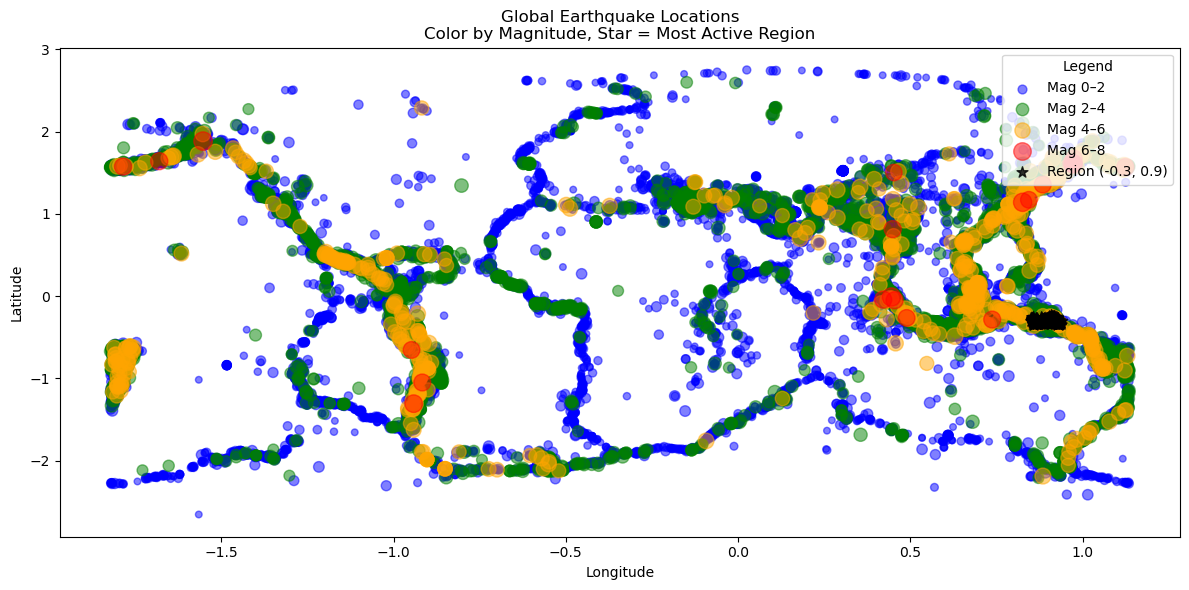

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../Day_8/preprocessed_earthquake_data.csv')

if not df.empty and {'latitude', 'longitude', 'mag'}.issubset(df.columns):
    plt.figure(figsize=(12, 6))

    # Magnitude bins and colors
    bins = [0, 2, 4, 6, 8]
    labels = ['0–2', '2–4', '4–6', '6–8']
    colors = dict(zip(labels, ['blue', 'green', 'orange', 'red']))
    df['mag_range'] = pd.cut(df['mag'], bins=bins, labels=labels, include_lowest=True)
    sizes = (df['mag'] - df['mag'].min() + 0.1) * 20

    # Top region detection
    df['lat_bin'], df['lon_bin'] = df['latitude'].round(1), df['longitude'].round(1)
    top = df.groupby(['lat_bin', 'lon_bin']).size().reset_index(name='count').nlargest(1, 'count')
    top_lat, top_lon = top.iloc[0][['lat_bin', 'lon_bin']]

    # Plot by magnitude
    for label in labels:
        subset = df[df['mag_range'] == label]
        plt.scatter(subset['longitude'], subset['latitude'], s=sizes[subset.index],
                    c=colors[label], alpha=0.5, label=f'Mag {label}')

    # Highlight most frequent region
    region = df[(df['lat_bin'] == top_lat) & (df['lon_bin'] == top_lon)]
    plt.scatter(region['longitude'], region['latitude'], s=sizes[region.index],
                c='black', marker='*', alpha=0.8, label=f'Region ({top_lat}, {top_lon})')

    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Global Earthquake Locations\nColor by Magnitude, Star = Most Active Region')
    plt.legend(loc='upper right', frameon=True, title='Legend')
    plt.tight_layout()
    plt.show()
else:
    print('DataFrame empty or missing latitude/longitude/mag; cannot plot Q4.')